In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import pandas as pd
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

from classifiers import classifier_training

In [2]:
# --- CONFIGURATION ---
BATCH_SIZE = 48
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/list_attr_celeba.csv"
IMAGE_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/img_align_celeba"
PATH_CHECKPOINT = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/outputs/cnn_classfier"
NUM_CLASSES = 40
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
WEIGHT_DECAY = 1e-4

# Tạo thư mục checkpoint
os.makedirs(PATH_CHECKPOINT, exist_ok=True)

In [3]:
# --- 1. UTILS: Padding & CBAM Modules ---

class SquarePadResize:
    """
    Resize chiều lớn nhất về target_size, sau đó thêm padding đen 
    để ảnh trở thành hình vuông (target_size x target_size).
    Giữ nguyên tỉ lệ ảnh (Aspect Ratio).
    """
    def __init__(self, target_size):
        self.target_size = target_size

    def __call__(self, img):
        w, h = img.size
        max_dim = max(w, h)
        scale = self.target_size / max_dim
        new_w, new_h = int(w * scale), int(h * scale)
        img = img.resize((new_w, new_h), Image.BICUBIC)
        
        # Tạo ảnh nền đen
        new_img = Image.new("RGB", (self.target_size, self.target_size), (0, 0, 0))
        # Paste ảnh gốc vào giữa
        new_img.paste(img, ((self.target_size - new_w) // 2, (self.target_size - new_h) // 2))
        return new_img

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50_CBAM, self).__init__()
        # Load pre-trained ResNet50
        base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        # Tách các layer để chèn CBAM vào giữa các stage
        self.stem = nn.Sequential(
            base_model.conv1, base_model.bn1, base_model.relu, base_model.maxpool
        )
        self.layer1 = base_model.layer1
        self.cbam1 = CBAMBlock(256) # ResNet50 layer1 out channels = 256
        
        self.layer2 = base_model.layer2
        self.cbam2 = CBAMBlock(512) # ResNet50 layer2 out channels = 512
        
        self.layer3 = base_model.layer3
        self.cbam3 = CBAMBlock(1024) # ResNet50 layer3 out channels = 1024
        
        self.layer4 = base_model.layer4
        self.cbam4 = CBAMBlock(2048) # ResNet50 layer4 out channels = 2048
        
        self.avgpool = base_model.avgpool
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.stem(x)
        
        x = self.layer1(x)
        x = self.cbam1(x) # Apply CBAM
        
        x = self.layer2(x)
        x = self.cbam2(x) # Apply CBAM
        
        x = self.layer3(x)
        x = self.cbam3(x) # Apply CBAM
        
        x = self.layer4(x)
        x = self.cbam4(x) # Apply CBAM
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# --- 2. DATASET & PREPARATION ---

class CelebADataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        self.img_names = self.df.index.tolist() # Image_id is index
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        
        # Lấy labels, chuyển -1 thành 0
        # Label trong CSV CelebA: 1 (có), -1 (không)
        labels = torch.tensor(self.df.iloc[idx].values, dtype=torch.float32)
        labels[labels == -1] = 0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, labels

In [4]:
# Load CSV
print("Loading CSV metadata...")
df_attr = pd.read_csv(CSV_PATH, index_col=0)
attribute_names = df_attr.columns.tolist()

# Split Train/Val (90/10)
train_df, val_df = train_test_split(df_attr, test_size=0.1, random_state=42)

# Tính toán pos_weight cho Loss Function dựa trên tập Train
# pos_weight = (num_neg) / (num_pos) cho từng class
print("Calculating positive weights for loss function...")
train_labels = train_df.replace(-1, 0).values
num_pos = np.sum(train_labels, axis=0)
num_neg = len(train_df) - num_pos
# Thêm epsilon để tránh chia cho 0
pos_weights_tensor = torch.tensor(num_neg / (num_pos + 1e-5), dtype=torch.float32).to(DEVICE)

# Transforms
train_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE), # Custom resize & pad
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0) # Random Erasing
])

val_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CelebADataset(train_df, IMAGE_PATH, transform=train_transform)
val_dataset = CelebADataset(val_df, IMAGE_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True,prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True,prefetch_factor=4)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

Loading CSV metadata...
Calculating positive weights for loss function...
Train size: 89344 | Val size: 9928


In [5]:
# --- 3. MODEL, OPTIMIZER, LOSS SETUP ---

print(f"Initializing ResNet50 + CBAM on {DEVICE}...")
model = ResNet50_CBAM(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Loss function với pos_weight xử lý imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Initializing ResNet50 + CBAM on cuda...


In [ ]:
# --- 4. TRAINING LOOP ---
print("Starting training loop...")

# Biến lưu lịch sử (nếu muốn vẽ biểu đồ sau này)
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    # --- TRAIN ---
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
    
    for images, labels in train_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        train_bar.set_postfix(loss=loss.item())
    
    epoch_train_loss = running_loss / len(train_dataset)
    history['train_loss'].append(epoch_train_loss)
    
    # Update Scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # --- VALIDATE ---
    model.eval()
    val_running_loss = 0.0
    
    # Lưu prediction và target để tính accuracy cho từng attribute
    all_preds = []
    all_targets = []
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]")
    
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            
            # Tính xác suất (Sigmoid)
            probs = torch.sigmoid(outputs)
            
            all_preds.append(probs.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    epoch_val_loss = val_running_loss / len(val_dataset)
    history['val_loss'].append(epoch_val_loss)

    # --- TÍNH TOÁN METRICS CHO TỪNG ATTRIBUTE ---
    all_preds = np.concatenate(all_preds, axis=0)   # Shape: (N_val, 40)
    all_targets = np.concatenate(all_targets, axis=0) # Shape: (N_val, 40)
    
    # Chuyển xác suất thành nhãn binary (Threshold = 0.5)
    binary_preds = (all_preds > 0.5).astype(int)
    
    # Tính accuracy cho từng cột (từng attribute)
    # Correct prediction: (pred == target)
    correct_counts = np.sum(binary_preds == all_targets, axis=0)
    acc_per_attr = correct_counts / len(val_dataset)
    
    mean_acc = np.mean(acc_per_attr)

    # --- IN KẾT QUẢ ---
    print(f"\n--- Epoch {epoch} Report ---")
    print(f"LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Mean Val Acc: {mean_acc:.4f}")
    
    print("-" * 60)
    print(f"{'Attribute':<25} | {'Accuracy':<10} | {'Sample Prob (Mean)':<15}")
    print("-" * 60)
    
    # In chi tiết từng attribute
    for i, attr_name in enumerate(attribute_names):
        # Sample Prob Mean: Xác suất trung bình model dự đoán cho class này (để xem model có bị bias về 0 hay 1 ko)
        mean_prob = np.mean(all_preds[:, i])
        print(f"{attr_name:<25} | {acc_per_attr[i]:.4f}     | {mean_prob:.4f}")
    print("-" * 60)

    # --- SAVE CHECKPOINT ---
    # Lưu định kỳ mỗi 5 epoch
    if epoch % 5 == 0:
        ckpt_name = f"resnet50_cbam_epoch_{epoch}.pth"
        save_path = os.path.join(PATH_CHECKPOINT, ckpt_name)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_val_loss,
        }, save_path)
        print(f"Saved checkpoint: {save_path}")

    # Lưu best model (nếu cần)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), os.path.join(PATH_CHECKPOINT, "best_model.pth"))

print("Training Complete.")

Starting training loop...


Epoch 1/30 [Val]: 100%|██████████| 207/207 [00:25<00:00,  8.17it/s]



--- Epoch 1 Report ---
LR: 0.001000 | Train Loss: 0.5774 | Val Loss: 0.5345 | Mean Val Acc: 0.8356
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
5_o_Clock_Shadow          | 0.9030     | 0.1783
Arched_Eyebrows           | 0.7971     | 0.3415
Attractive                | 0.7294     | 0.3352
Bags_Under_Eyes           | 0.7553     | 0.3684
Bald                      | 0.9243     | 0.1074
Bangs                     | 0.9374     | 0.2002
Big_Lips                  | 0.7350     | 0.3487
Big_Nose                  | 0.7657     | 0.3681
Black_Hair                | 0.8047     | 0.3820
Blond_Hair                | 0.8984     | 0.2576
Blurry                    | 0.5986     | 0.4789
Brown_Hair                | 0.8570     | 0.1986
Bushy_Eyebrows            | 0.8981     | 0.2086
Chubby                    | 0.8122     | 0.2648
Double_Chin               | 0.8160     | 0.244

Epoch 2/30 [Val]: 100%|██████████| 207/207 [00:24<00:00,  8.39it/s]



--- Epoch 2 Report ---
LR: 0.001000 | Train Loss: 0.4810 | Val Loss: 0.4581 | Mean Val Acc: 0.8588
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
5_o_Clock_Shadow          | 0.9040     | 0.1872
Arched_Eyebrows           | 0.7713     | 0.4198
Attractive                | 0.8088     | 0.5653
Bags_Under_Eyes           | 0.7784     | 0.3610
Bald                      | 0.9356     | 0.0949
Bangs                     | 0.9387     | 0.2120
Big_Lips                  | 0.6847     | 0.4163
Big_Nose                  | 0.7951     | 0.3495
Black_Hair                | 0.8799     | 0.3100
Blond_Hair                | 0.9212     | 0.2352
Blurry                    | 0.8603     | 0.2331
Brown_Hair                | 0.7628     | 0.4261
Bushy_Eyebrows            | 0.8527     | 0.2846
Chubby                    | 0.8338     | 0.2510
Double_Chin               | 0.8851     | 0.176

...


--- Epoch 28 Report ---
LR: 0.000000 | Train Loss: 0.3118 | Val Loss: 0.4109 | Mean Val Acc: 0.8929
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
5_o_Clock_Shadow          | 0.9108     | 0.1846
Arched_Eyebrows           | 0.8314     | 0.3639
Attractive                | 0.8281     | 0.5146
Bags_Under_Eyes           | 0.8070     | 0.3293
Bald                      | 0.9843     | 0.0339
Bangs                     | 0.9497     | 0.1933
Big_Lips                  | 0.6995     | 0.4258
Big_Nose                  | 0.8056     | 0.3553
Black_Hair                | 0.8944     | 0.3072
Blond_Hair                | 0.9401     | 0.1954
Blurry                    | 0.9427     | 0.0997
Brown_Hair                | 0.8334     | 0.3216
Bushy_Eyebrows            | 0.8803     | 0.2404
Chubby                    | 0.9275     | 0.1191
Double_Chin               | 0.9399     | 0.09

Epoch 29/30 [Val]: 100%|██████████| 207/207 [00:24<00:00,  8.52it/s]



--- Epoch 29 Report ---
LR: 0.000000 | Train Loss: 0.3114 | Val Loss: 0.4081 | Mean Val Acc: 0.8921
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
5_o_Clock_Shadow          | 0.9117     | 0.1840
Arched_Eyebrows           | 0.8329     | 0.3618
Attractive                | 0.8261     | 0.5024
Bags_Under_Eyes           | 0.8056     | 0.3317
Bald                      | 0.9841     | 0.0346
Bangs                     | 0.9486     | 0.1951
Big_Lips                  | 0.6974     | 0.4271
Big_Nose                  | 0.8018     | 0.3623
Black_Hair                | 0.8946     | 0.3067
Blond_Hair                | 0.9397     | 0.1955
Blurry                    | 0.9397     | 0.1036
Brown_Hair                | 0.8381     | 0.3144
Bushy_Eyebrows            | 0.8787     | 0.2423
Chubby                    | 0.9245     | 0.1240
Double_Chin               | 0.9353     | 0.10

Epoch 30/30 [Val]: 100%|██████████| 207/207 [00:24<00:00,  8.51it/s]



--- Epoch 30 Report ---
LR: 0.000000 | Train Loss: 0.3114 | Val Loss: 0.4126 | Mean Val Acc: 0.8930
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
5_o_Clock_Shadow          | 0.9152     | 0.1772
Arched_Eyebrows           | 0.8320     | 0.3629
Attractive                | 0.8262     | 0.5163
Bags_Under_Eyes           | 0.8032     | 0.3368
Bald                      | 0.9847     | 0.0333
Bangs                     | 0.9480     | 0.1962
Big_Lips                  | 0.7036     | 0.4191
Big_Nose                  | 0.8055     | 0.3559
Black_Hair                | 0.8938     | 0.3060
Blond_Hair                | 0.9409     | 0.1949
Blurry                    | 0.9464     | 0.0926
Brown_Hair                | 0.8315     | 0.3262
Bushy_Eyebrows            | 0.8804     | 0.2414
Chubby                    | 0.9257     | 0.1215
Double_Chin               | 0.9396     | 0.09

In [7]:
# --- 5. INFERENCE ON SINGLE IMAGE ---

def inference_single_image(model, image_path, transform, attribute_names, device, threshold=0.5):
    """
    Inference cho 1 ảnh, in ra ground truth, prediction probability và accuracy
    
    Args:
        model: Trained model
        image_path: Đường dẫn đến ảnh cần test
        transform: Transform để preprocess ảnh
        attribute_names: List tên các attributes
        device: Device để chạy inference
        threshold: Ngưỡng để chuyển prob thành binary prediction (default=0.5)
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Get ground truth label from CSV
    img_name = os.path.basename(image_path)
    if img_name not in df_attr.index:
        print(f"Warning: {img_name} not found in CSV. Cannot get ground truth.")
        gt_labels = None
    else:
        gt_labels = df_attr.loc[img_name].values
        gt_labels = np.where(gt_labels == -1, 0, gt_labels)  # Convert -1 to 0
    
    # Preprocess image
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]  # Shape: (40,)
    
    # Convert probabilities to binary predictions
    binary_preds = (probs > threshold).astype(int)
    
    # Print results
    print(f"\n{'='*80}")
    print(f"Inference Result for: {img_name}")
    print(f"{'='*80}")
    print(f"{'Attribute':<25} | {'Ground Truth':<13} | {'Pred Prob':<10} | {'Prediction':<11} | {'Correct':<7}")
    print(f"{'-'*80}")
    
    correct_count = 0
    total_count = len(attribute_names)
    
    for i, attr_name in enumerate(attribute_names):
        pred_prob = probs[i]
        pred_label = binary_preds[i]
        
        if gt_labels is not None:
            gt_label = int(gt_labels[i])
            is_correct = (pred_label == gt_label)
            correct_count += int(is_correct)
            correct_str = "✓" if is_correct else "✗"
            gt_str = str(gt_label)
        else:
            gt_str = "N/A"
            correct_str = "N/A"
        
        print(f"{attr_name:<25} | {gt_str:<13} | {pred_prob:.4f}     | {pred_label:<11} | {correct_str:<7}")
    
    print(f"{'-'*80}")
    
    if gt_labels is not None:
        accuracy = correct_count / total_count
        print(f"\nImage Accuracy: {correct_count}/{total_count} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    else:
        print("\nNo ground truth available - cannot calculate accuracy")
    
    print(f"{'='*80}\n")
    
    return probs, binary_preds, gt_labels

# --- TEST INFERENCE ---
# Load best model
print("Loading best model for inference...")
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth")))
model.eval()

# Chọn 1 ảnh ngẫu nhiên từ validation set để test
sample_img_name = val_df.index[320]  # Lấy ảnh đầu tiên trong val set
sample_img_path = os.path.join(IMAGE_PATH, sample_img_name)

print(f"Testing inference on: {sample_img_name}")

# Run inference
probs, preds, gt = inference_single_image(
    model=model,
    image_path=sample_img_path,
    transform=val_transform,
    attribute_names=attribute_names,
    device=DEVICE,
    threshold=0.5
)

# --- TEST VỚI NHIỀU ẢNH (Optional) ---
print("\n" + "="*80)
print("Testing on multiple random images from validation set:")
print("="*80)

# Test 3 ảnh ngẫu nhiên
np.random.seed(42)
random_indices = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for idx in random_indices:
    img_name = val_df.index[idx]
    img_path = os.path.join(IMAGE_PATH, img_name)
    
    inference_single_image(
        model=model,
        image_path=img_path,
        transform=val_transform,
        attribute_names=attribute_names,
        device=DEVICE,
        threshold=0.9
    )

Loading best model for inference...
Testing inference on: 084250.jpg

Inference Result for: 084250.jpg
Attribute                 | Ground Truth  | Pred Prob  | Prediction  | Correct
--------------------------------------------------------------------------------
5_o_Clock_Shadow          | 0             | 0.0000     | 0           | ✓      
Arched_Eyebrows           | 1             | 0.9438     | 1           | ✓      
Attractive                | 0             | 0.7246     | 1           | ✗      
Bags_Under_Eyes           | 0             | 0.0040     | 0           | ✓      
Bald                      | 0             | 0.0000     | 0           | ✓      
Bangs                     | 0             | 0.0043     | 0           | ✓      
Big_Lips                  | 1             | 0.8196     | 1           | ✓      
Big_Nose                  | 0             | 0.0093     | 0           | ✓      
Black_Hair                | 0             | 0.0304     | 0           | ✓      
Blond_Hair                

Visualizing Grad-CAM for attribute: Brown_Hair

=== Grad-CAM for POSITIVE class (attribute present) ===


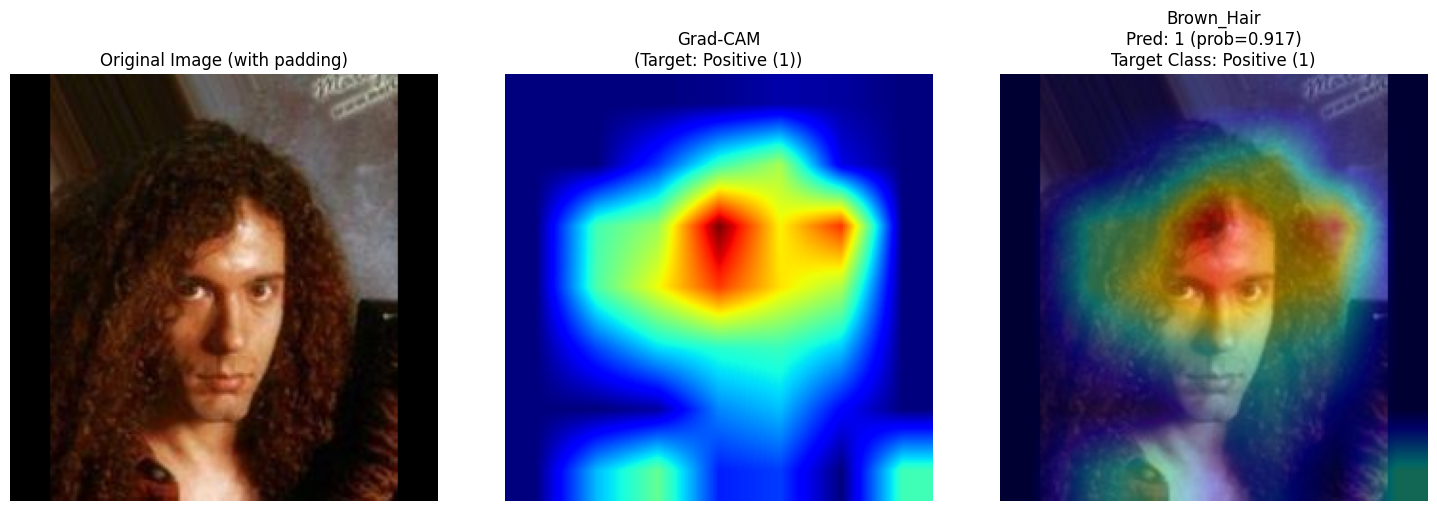


=== Grad-CAM for NEGATIVE class (attribute absent) ===


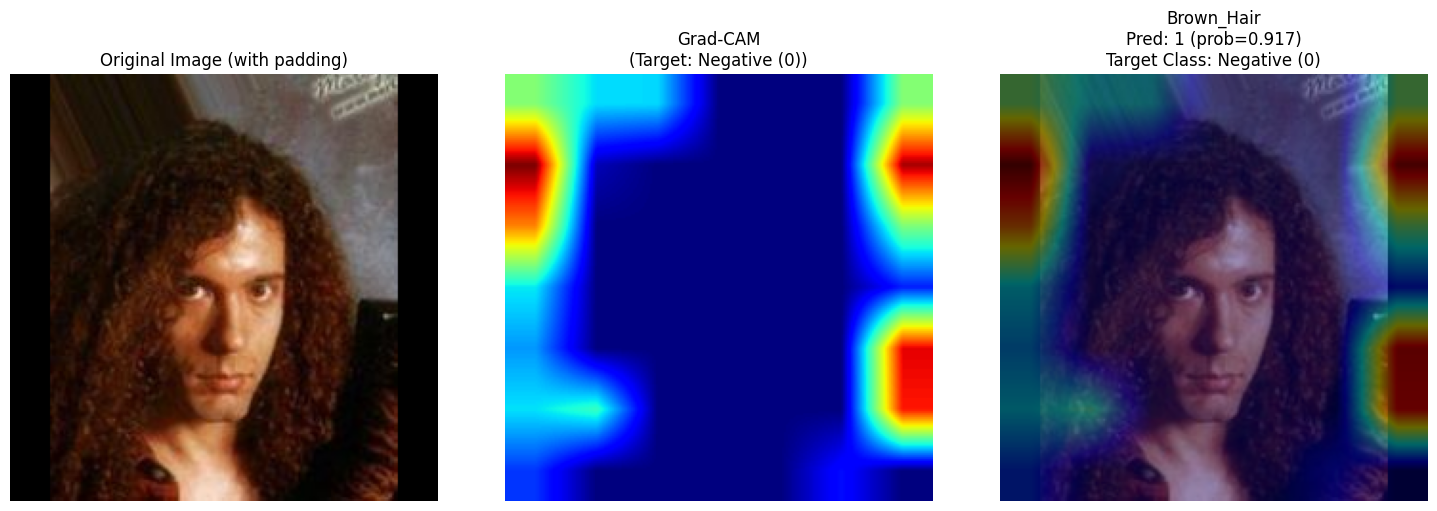

In [8]:
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handles = []
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def register_hooks(self):
        """Register forward and backward hooks"""
        # Clear ALL existing hooks and reset the flag
        self.target_layer._backward_hooks.clear()
        self.target_layer._forward_hooks.clear()
        self.target_layer._is_full_backward_hook = None  # Reset the flag
        
        self.handles.append(
            self.target_layer.register_forward_hook(self.save_activation)
        )
        self.handles.append(
            self.target_layer.register_full_backward_hook(self.save_gradient)
        )
    
    def remove_hooks(self):
        """Remove all registered hooks"""
        for handle in self.handles:
            handle.remove()
        self.handles = []
        # Reset flag after removing hooks
        self.target_layer._is_full_backward_hook = None
    
    def generate_cam(self, input_tensor, attribute_idx, target_class=1):
        """
        Generate CAM for specific attribute
        
        Args:
            input_tensor: Input image tensor
            attribute_idx: Index of attribute to visualize
            target_class: 0 for negative prediction, 1 for positive prediction
        """
        # Clone and enable gradient computation
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)
        
        # Get score for specific attribute
        score = output[0, attribute_idx]
        
        # For negative class (class 0), we want to maximize the negative score
        # This means we use negative gradient
        if target_class == 0:
            score = -score  # Invert for negative class
        
        # Backward pass
        self.model.zero_grad()
        score.backward(retain_graph=True)
        
        # Calculate weights (global average pooling of gradients)
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        
        # Calculate weighted combination of activation maps
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        
        # Apply ReLU (only positive influences)
        cam = F.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.squeeze().cpu().detach().numpy()

def visualize_gradcam(model, image_path, attribute_idx, attribute_name, 
                      transform, device, target_class=1, alpha=0.4):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # ===== FIX: Apply same transform to get aligned original image =====
    # Create transform WITHOUT normalization for visualization
    viz_transform = transforms.Compose([
        SquarePadResize(IMAGE_SIZE),
        transforms.ToTensor()  # No normalization
    ])
    
    # Get original image with padding (same as model input)
    original_padded = viz_transform(image)  # Shape: (3, 224, 224)
    original_padded = original_padded.permute(1, 2, 0).numpy()  # Shape: (224, 224, 3)
    original_padded = (original_padded * 255).astype(np.uint8)  # Convert to uint8
    
    # Initialize Grad-CAM
    gradcam = GradCAM(model, model.layer4)
    gradcam.register_hooks()
    
    try:
        # Generate CAM
        cam = gradcam.generate_cam(input_tensor, attribute_idx, target_class)
        
        # Resize CAM to match image size
        cam_resized = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        
        # Create heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Overlay heatmap on PADDED original image
        overlayed = heatmap * alpha + original_padded * (1 - alpha)
        overlayed = overlayed.astype(np.uint8)
        
        # Get prediction
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.sigmoid(output)[0, attribute_idx].item()
            pred = 1 if prob > 0.5 else 0
        
        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(original_padded)
        axes[0].set_title("Original Image (with padding)")
        axes[0].axis('off')
        
        axes[1].imshow(cam_resized, cmap='jet')
        axes[1].set_title(f"Grad-CAM\n(Target: {'Negative (0)' if target_class == 0 else 'Positive (1)'})")
        axes[1].axis('off')
        
        axes[2].imshow(overlayed)
        class_name = "Negative (0)" if target_class == 0 else "Positive (1)"
        axes[2].set_title(f"{attribute_name}\nPred: {pred} (prob={prob:.3f})\nTarget Class: {class_name}")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    finally:
        gradcam.remove_hooks()
# --- USAGE EXAMPLE ---
# Load best model
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth")))
model.eval()

# Choose an image and attribute
sample_img_path = os.path.join(IMAGE_PATH, val_df.index[132])
attr_idx = attribute_names.index("Brown_Hair")  # Example: Smiling attribute

print(f"Visualizing Grad-CAM for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE prediction (where attribute is present)
print("\n=== Grad-CAM for POSITIVE class (attribute present) ===")
visualize_gradcam(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                 val_transform, DEVICE, target_class=1)

# Visualize for NEGATIVE prediction (where attribute is absent)
print("\n=== Grad-CAM for NEGATIVE class (attribute absent) ===")
visualize_gradcam(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                 val_transform, DEVICE, target_class=0)

Visualizing Grad-CAM++ for attribute: Brown_Hair

=== Grad-CAM++ for POSITIVE class ===


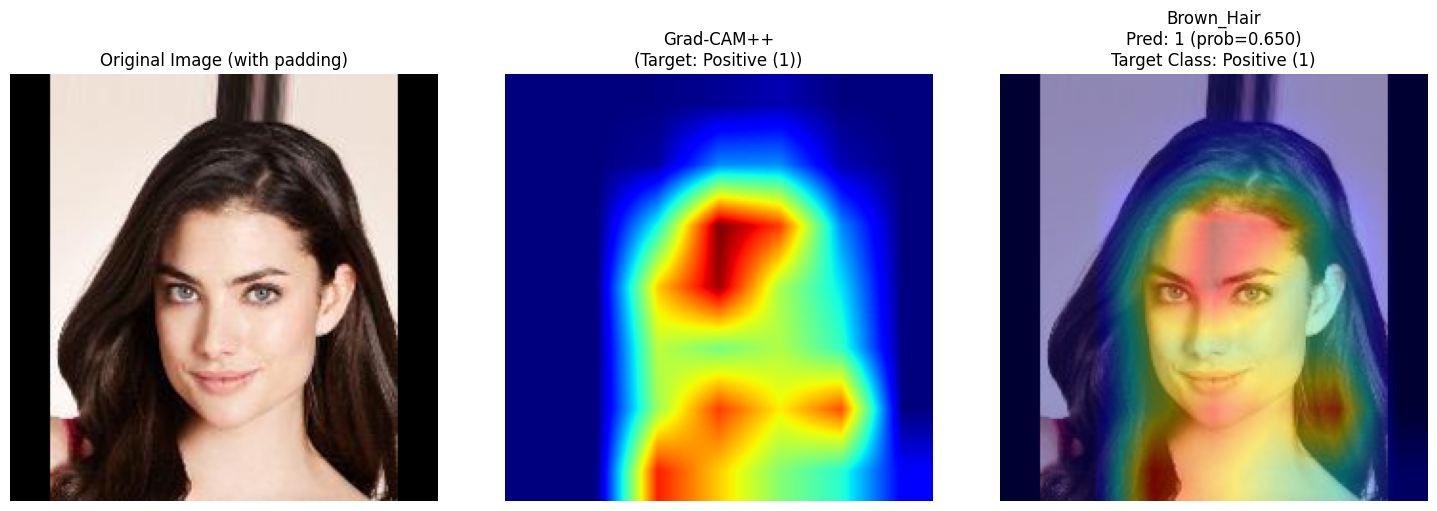


=== Grad-CAM++ for NEGATIVE class ===


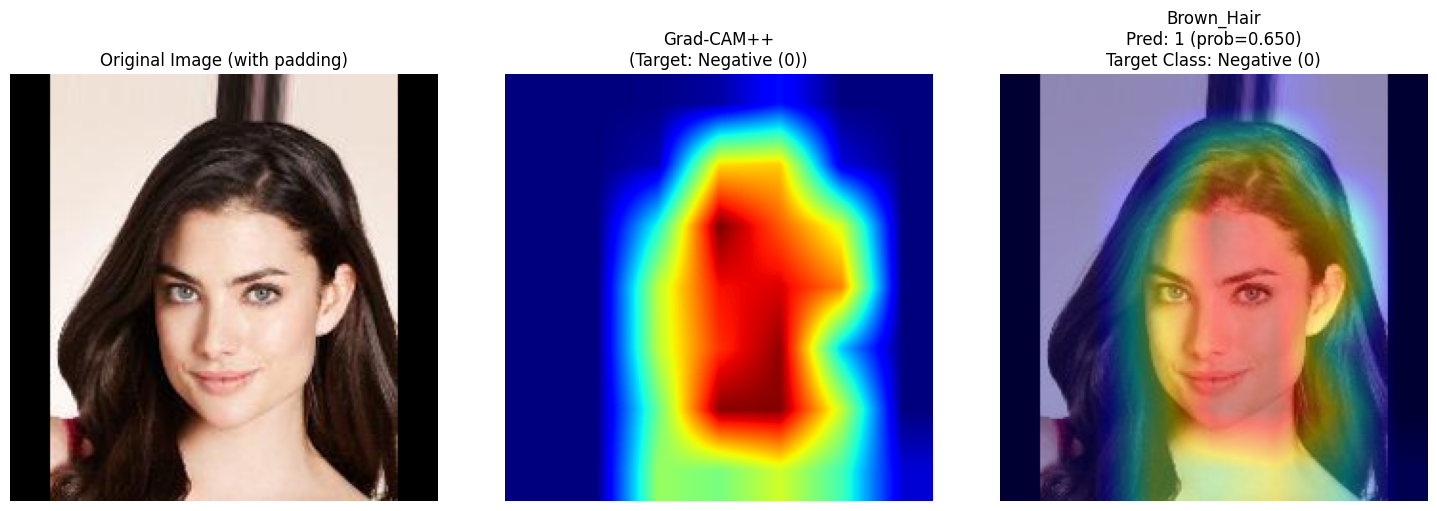

In [13]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handles = []
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def register_hooks(self):
        """Register forward and backward hooks"""
        # Clear ALL existing hooks and reset the flag
        self.target_layer._backward_hooks.clear()
        self.target_layer._forward_hooks.clear()
        self.target_layer._is_full_backward_hook = None
        
        self.handles.append(
            self.target_layer.register_forward_hook(self.save_activation)
        )
        self.handles.append(
            self.target_layer.register_full_backward_hook(self.save_gradient)
        )
    
    def remove_hooks(self):
        """Remove all registered hooks"""
        for handle in self.handles:
            handle.remove()
        self.handles = []
        self.target_layer._is_full_backward_hook = None
    
    def generate_cam(self, input_tensor, attribute_idx, target_class=1):
        """
        Generate CAM++ for specific attribute
        
        Args:
            input_tensor: Input image tensor
            attribute_idx: Index of attribute to visualize
            target_class: 0 for negative prediction, 1 for positive prediction
        """
        # Clone and enable gradient computation
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)
        
        # Get score for specific attribute
        score = output[0, attribute_idx]
        
        # For negative class (class 0), invert the score
        if target_class == 0:
            score = -score
        
        # Backward pass
        self.model.zero_grad()
        score.backward(retain_graph=True)
        
        grads = self.gradients  # Shape: (B, C, H, W)
        activations = self.activations  # Shape: (B, C, H, W)
        
        # GradCAM++ formula
        grad_2 = grads.pow(2)
        grad_3 = grad_2 * grads
        
        # Calculate alpha with numerical stability
        eps = 1e-8
        spatial_sum = (activations * grad_3).sum(dim=(2, 3), keepdim=True)
        denom = 2 * grad_2 + spatial_sum
        denom = torch.clamp(denom, min=eps)
        
        alphas = grad_2 / denom
        
        # Calculate weights
        weights = (alphas * torch.relu(grads)).sum(dim=(2, 3), keepdim=True)
        
        # Calculate CAM
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = torch.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        
        return cam.squeeze().cpu().detach().numpy()

def visualize_gradcam_plusplus(model, image_path, attribute_idx, attribute_name, 
                               transform, device, target_class=1, alpha=0.4):
    """Visualization function for GradCAM++"""
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Create transform WITHOUT normalization for visualization
    viz_transform = transforms.Compose([
        SquarePadResize(IMAGE_SIZE),
        transforms.ToTensor()
    ])
    
    # Get original image with padding
    original_padded = viz_transform(image)
    original_padded = original_padded.permute(1, 2, 0).numpy()
    original_padded = (original_padded * 255).astype(np.uint8)
    
    # Initialize Grad-CAM++
    gradcam_pp = GradCAMPlusPlus(model, model.cbam4)
    gradcam_pp.register_hooks()
    
    try:
        # Generate CAM
        cam = gradcam_pp.generate_cam(input_tensor, attribute_idx, target_class)
        
        # Resize CAM to match image size
        cam_resized = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        
        # Create heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Overlay heatmap
        overlayed = heatmap * alpha + original_padded * (1 - alpha)
        overlayed = overlayed.astype(np.uint8)
        
        # Get prediction
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.sigmoid(output)[0, attribute_idx].item()
            pred = 1 if prob > 0.5 else 0
        
        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(original_padded)
        axes[0].set_title("Original Image (with padding)")
        axes[0].axis('off')
        
        axes[1].imshow(cam_resized, cmap='jet')
        axes[1].set_title(f"Grad-CAM++\n(Target: {'Negative (0)' if target_class == 0 else 'Positive (1)'})")
        axes[1].axis('off')
        
        axes[2].imshow(overlayed)
        class_name = "Negative (0)" if target_class == 0 else "Positive (1)"
        axes[2].set_title(f"{attribute_name}\nPred: {pred} (prob={prob:.3f})\nTarget Class: {class_name}")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    finally:
        gradcam_pp.remove_hooks()

# --- USAGE EXAMPLE ---
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth")))
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[9927])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Grad-CAM++ for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Grad-CAM++ for POSITIVE class ===")
visualize_gradcam_plusplus(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                           val_transform, DEVICE, target_class=1)

# Visualize for NEGATIVE class
print("\n=== Grad-CAM++ for NEGATIVE class ===")
visualize_gradcam_plusplus(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                           val_transform, DEVICE, target_class=0)

Visualizing Integrated Gradients for attribute: Brown_Hair

=== Integrated Gradients for POSITIVE class ===


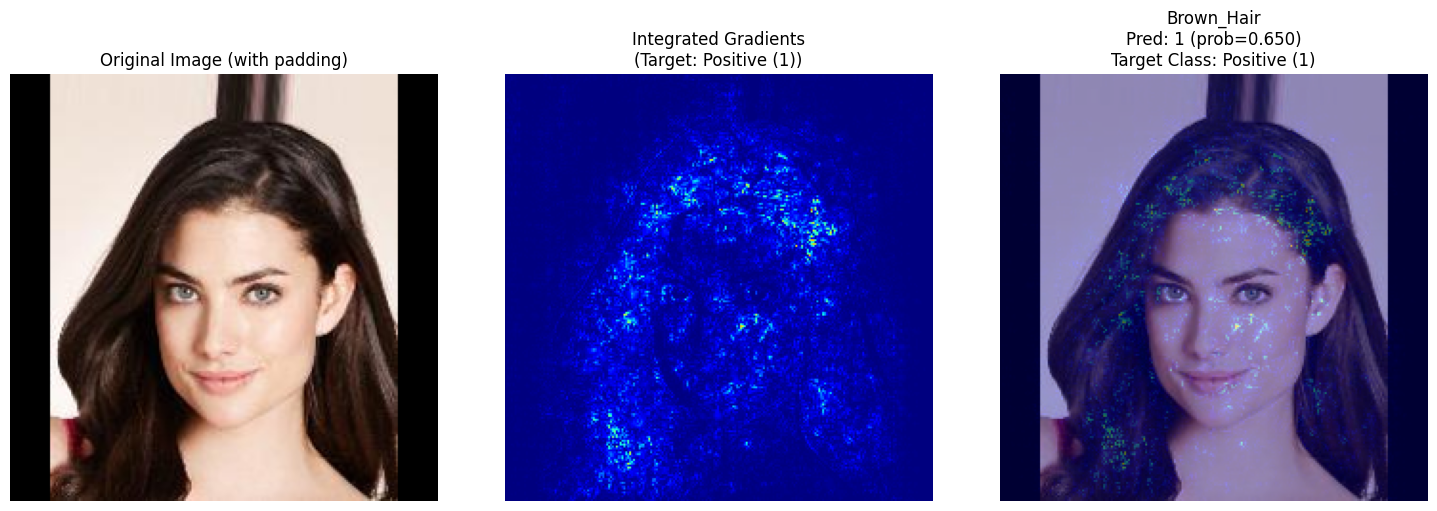


=== Integrated Gradients for NEGATIVE class ===


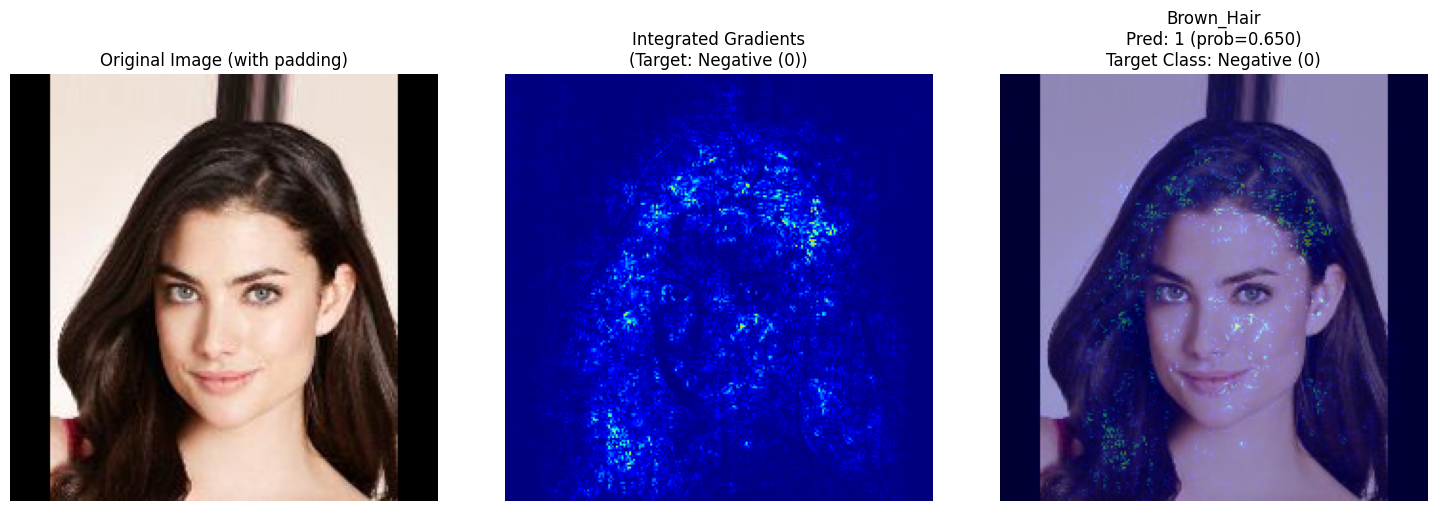

In [14]:
def integrated_gradients(model, input_image, attribute_idx, target_class=1, 
                        baseline=None, steps=50, device=None):
    """
    Tính Integrated Gradients cho một hình ảnh đầu vào.
    
    Args:
        model (torch.nn.Module): Mô hình CNN đã huấn luyện.
        input_image (torch.Tensor): Ảnh đầu vào (1, C, H, W).
        attribute_idx (int): Index của attribute cần giải thích.
        target_class (int): 0 cho negative prediction, 1 cho positive prediction.
        baseline (torch.Tensor): Ảnh nền (x'), mặc định là ảnh đen (zeros).
        steps (int): Số bước tích phân (m), thường từ 20-300.
        device: Device để tính toán.
    
    Returns:
        ig_attributions: Attribution map (1, C, H, W)
    """
    model.eval()
    
    if device is None:
        device = next(model.parameters()).device
    
    input_image = input_image.to(device)
    
    # 1. Thiết lập Baseline (x') là ảnh đen nếu không cung cấp
    if baseline is None:
        baseline = torch.zeros_like(input_image).to(device)
    else:
        baseline = baseline.to(device)

    # Tính hiệu số (x - x')
    diff = input_image - baseline

    # 2. Tính Gradient cho từng ảnh nội suy (batched để tăng tốc)
    batch_size = 10  # Chia nhỏ để tránh OOM
    all_grads = []
    
    for start in range(0, steps + 1, batch_size):
        end = min(start + batch_size, steps + 1)
        
        # Tạo các ảnh nội suy cho batch này
        interpolated_images = []
        for k in range(start, end):
            alpha = k / steps
            interpolated_image = baseline + alpha * diff
            interpolated_images.append(interpolated_image)
        
        # Gộp thành batch
        interpolated_inputs = torch.cat(interpolated_images, dim=0)
        interpolated_inputs.requires_grad_(True)
        
        # Forward pass
        outputs = model(interpolated_inputs)
        
        # Get score for specific attribute
        score = outputs[:, attribute_idx].sum()
        
        # For negative class (class 0), invert the score
        if target_class == 0:
            score = -score
        
        # Backward
        model.zero_grad()
        score.backward()
        
        # Lấy gradient
        grads = interpolated_inputs.grad.detach().clone()
        all_grads.append(grads)
        
        # Clear
        interpolated_inputs.grad = None
    
    # 3. Gộp tất cả gradients
    all_grads = torch.cat(all_grads, dim=0)  # (steps+1, C, H, W)
    
    # 4. Tính tích phân xấp xỉ (trung bình các gradient)
    avg_grads = torch.mean(all_grads, dim=0, keepdim=True)
    
    # 5. Nhân với hiệu số đầu vào (x - x')
    ig_attributions = diff * avg_grads
    
    return ig_attributions.detach()

def visualize_integrated_gradients(model, image_path, attribute_idx, attribute_name,
                                   transform, device, target_class=1, steps=50, alpha=0.4):
    """Visualization function for Integrated Gradients"""
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Create transform WITHOUT normalization for visualization
    viz_transform = transforms.Compose([
        SquarePadResize(IMAGE_SIZE),
        transforms.ToTensor()
    ])
    
    # Get original image with padding
    original_padded = viz_transform(image)
    original_padded = original_padded.permute(1, 2, 0).numpy()
    original_padded = (original_padded * 255).astype(np.uint8)
    
    # Compute Integrated Gradients
    ig_attr = integrated_gradients(
        model=model,
        input_image=input_tensor,
        attribute_idx=attribute_idx,
        target_class=target_class,
        steps=steps,
        device=device
    )
    
    # Convert attribution to visualization
    # Take absolute value and sum across channels
    ig_attr_abs = torch.abs(ig_attr).sum(dim=1).squeeze().cpu().numpy()
    
    # Normalize to [0, 1]
    ig_attr_norm = ig_attr_abs - ig_attr_abs.min()
    ig_attr_norm = ig_attr_norm / (ig_attr_norm.max() + 1e-8)
    
    # Resize to match image size
    ig_resized = cv2.resize(ig_attr_norm, (IMAGE_SIZE, IMAGE_SIZE))
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * ig_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay heatmap
    overlayed = heatmap * alpha + original_padded * (1 - alpha)
    overlayed = overlayed.astype(np.uint8)
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output)[0, attribute_idx].item()
        pred = 1 if prob > 0.5 else 0
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_padded)
    axes[0].set_title("Original Image (with padding)")
    axes[0].axis('off')
    
    axes[1].imshow(ig_resized, cmap='jet')
    axes[1].set_title(f"Integrated Gradients\n(Target: {'Negative (0)' if target_class == 0 else 'Positive (1)'})")
    axes[1].axis('off')
    
    axes[2].imshow(overlayed)
    class_name = "Negative (0)" if target_class == 0 else "Positive (1)"
    axes[2].set_title(f"{attribute_name}\nPred: {pred} (prob={prob:.3f})\nTarget Class: {class_name}")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- USAGE EXAMPLE ---
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth")))
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[9927])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Integrated Gradients for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Integrated Gradients for POSITIVE class ===")
visualize_integrated_gradients(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                               val_transform, DEVICE, target_class=1, steps=50)

# Visualize for NEGATIVE class
print("\n=== Integrated Gradients for NEGATIVE class ===")
visualize_integrated_gradients(model, sample_img_path, attr_idx, attribute_names[attr_idx],
                               val_transform, DEVICE, target_class=0, steps=50)